# Low-coherence bathymetric-edge encounters within FRAC=1

Select snapshots only after requiring strong local topographic exposure and weak vector coherence. Maps show the fixed core, local gradient directions, and the single Gaussian-weighted environmental vector. These are bathymetric-feature candidates; isolated seamounts should be distinguished from the continental slope during interpretation.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
import esp_pv_tools as ept
sns.set_theme(style="whitegrid", context="notebook")
palette = {"AE":"#c44e52", "CE":"#4c72b0"}

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
vertical = tilt.load_vert(paths, dic_form=False)
vertical = vertical[vertical.Depth < 1e3]


In [2]:
data = ept.load_cache()
focus = data[data.method.eq("esp_gaussian_1")].copy()
paths = tilt.Paths(); grid = tilt.load_grid(paths.grid, paths.z_r)
strong_threshold = focus.groupby("Cyc").PV_grad_topo_p90_local_mag.transform(lambda x: x.quantile(.90))
candidates = focus[(focus.PV_grad_topo_coherence <= .35) &
                   (focus.PV_grad_topo_p90_local_mag >= strong_threshold)].copy()
candidates["encounter_score"] = candidates.PV_grad_topo_p90_local_mag * (1-candidates.PV_grad_topo_coherence.clip(0,1))
events = (candidates.sort_values("encounter_score", ascending=False)
          .drop_duplicates(["Cyc","Eddy"])
          .groupby("Cyc", group_keys=False).head(20))
chosen = focus.merge(events[["Cyc","Eddy"]], on=["Cyc","Eddy"], how="inner")

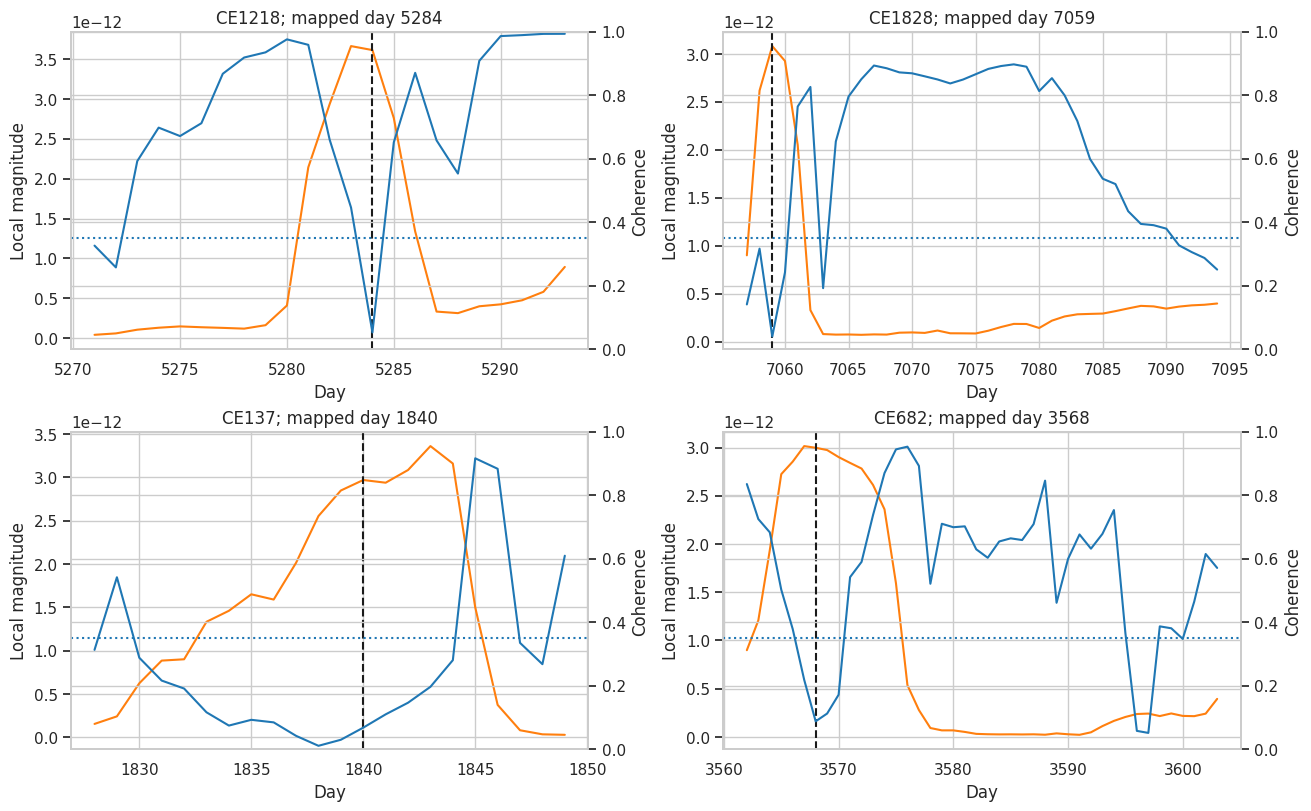

In [3]:
fig,axes=plt.subplots(2,2,figsize=(13,8),constrained_layout=True)
for ax, (_, event) in zip(axes.flat, events.iterrows()):
    track=chosen[(chosen.Cyc.eq(event.Cyc)) & (chosen.Eddy.eq(event.Eddy))].sort_values("Day")
    ax.plot(track.Day,track.PV_grad_topo_p90_local_mag,label="p90 local magnitude",color="tab:orange")
    ax2=ax.twinx(); ax2.plot(track.Day,track.PV_grad_topo_coherence,label="coherence",color="tab:blue")
    ax.axvline(event.Day,color="k",ls="--"); ax2.axhline(.35,color="tab:blue",ls=":")
    ax.set(title=f"{event.Cyc}{int(event.Eddy)}; mapped day {int(event.Day)}",xlabel="Day",ylabel="Local magnitude")
    ax2.set(ylim=(0,1),ylabel="Coherence")
plt.show()

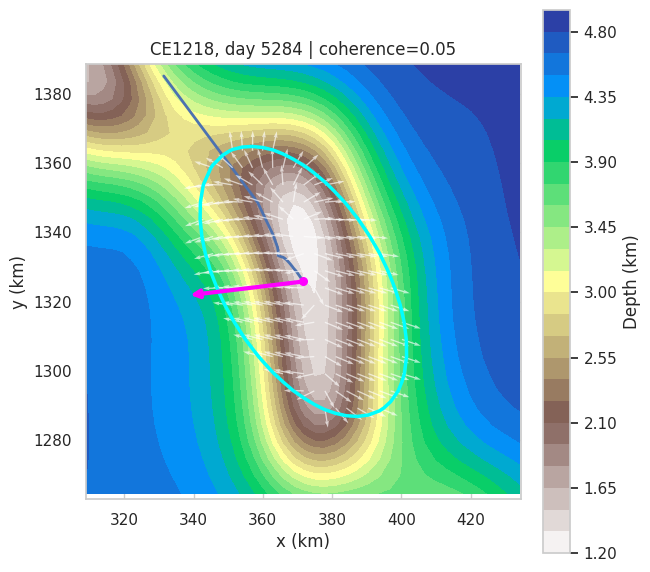

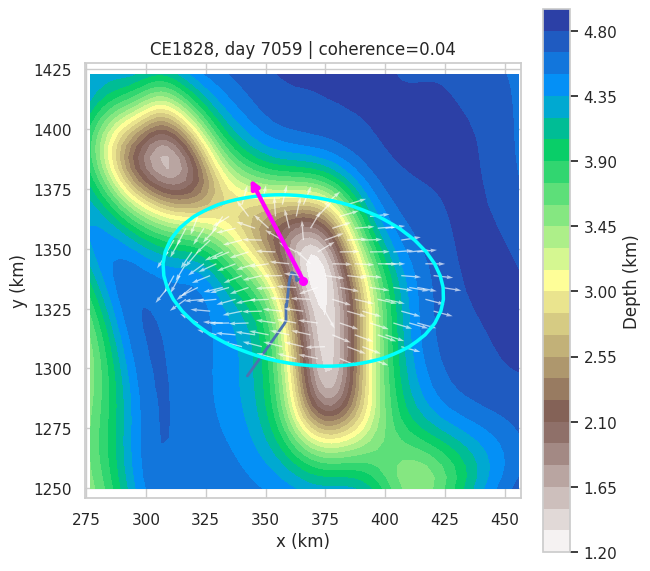

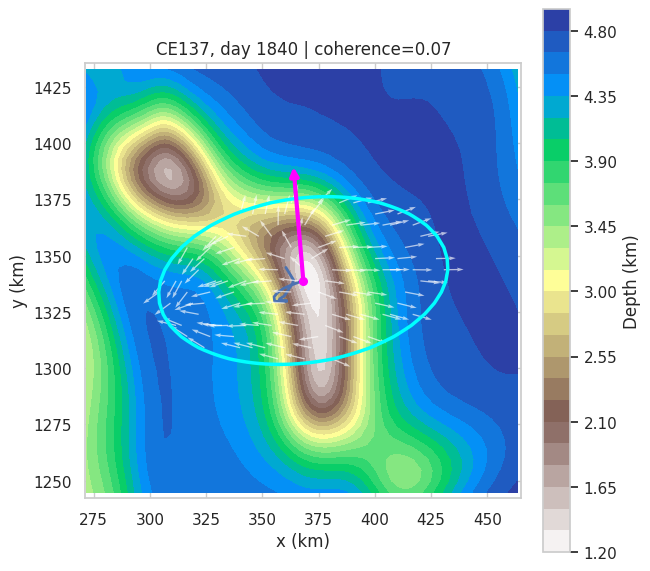

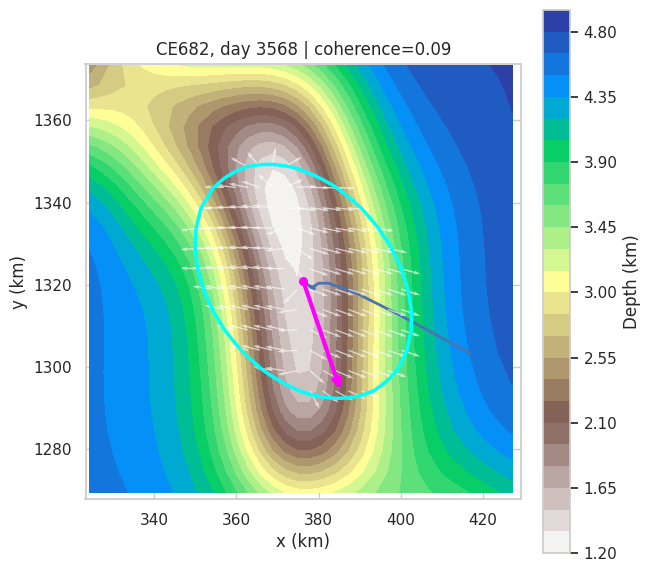

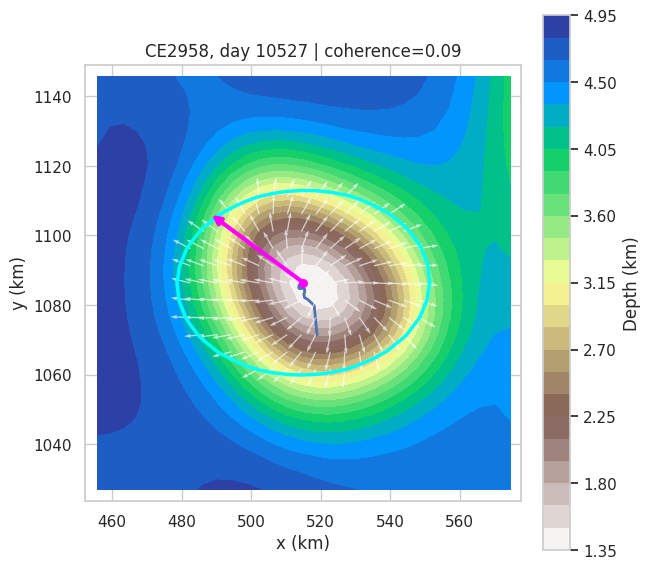

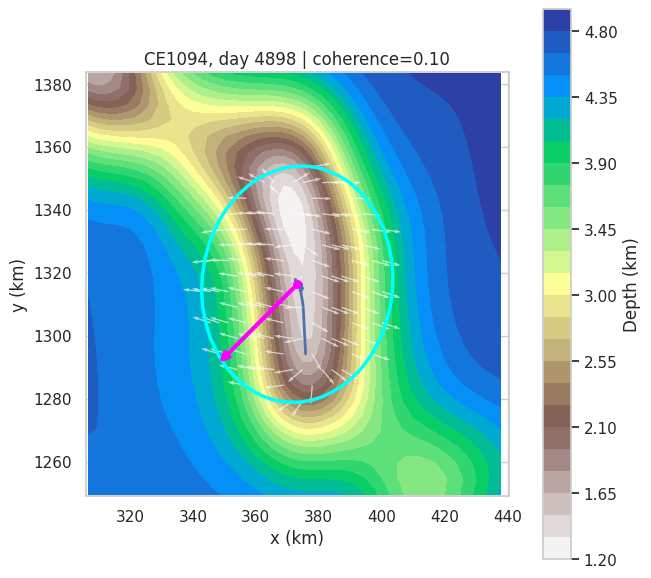

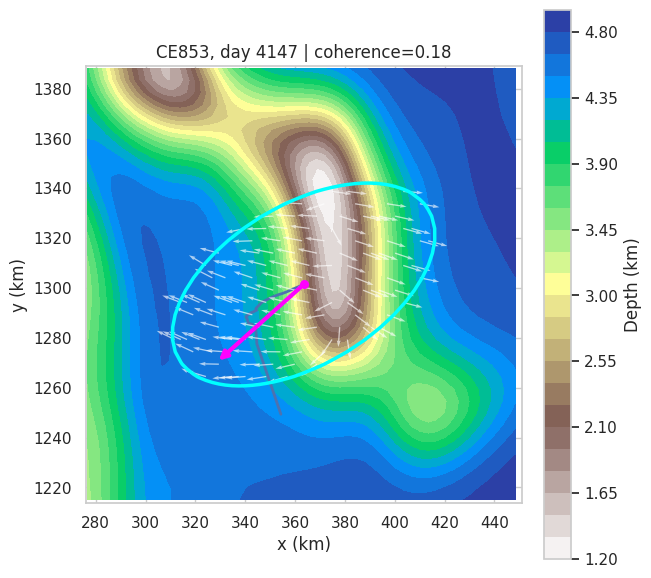

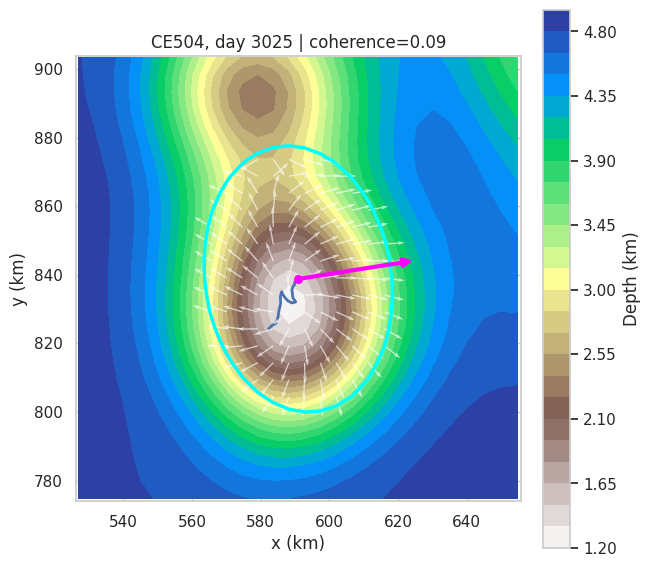

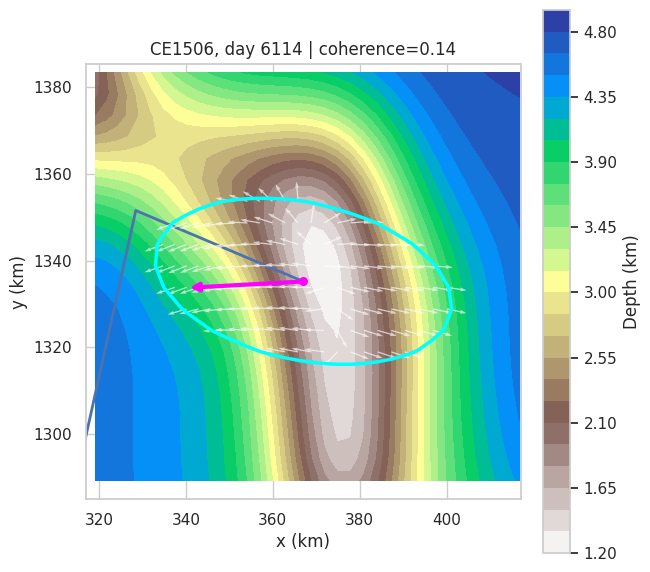

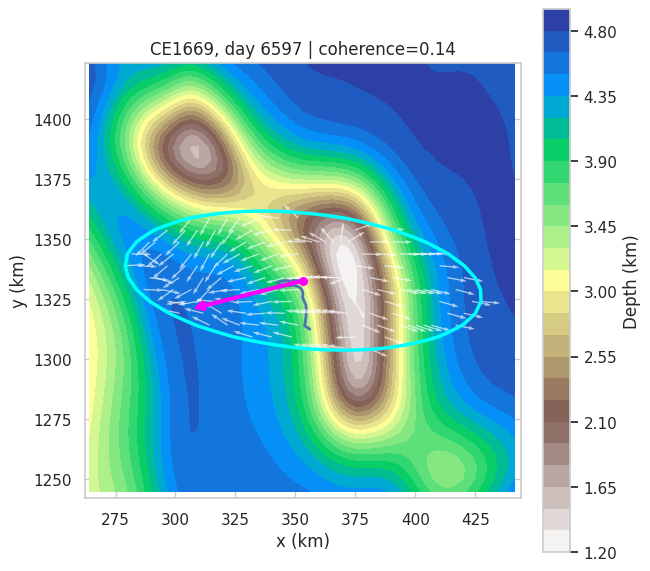

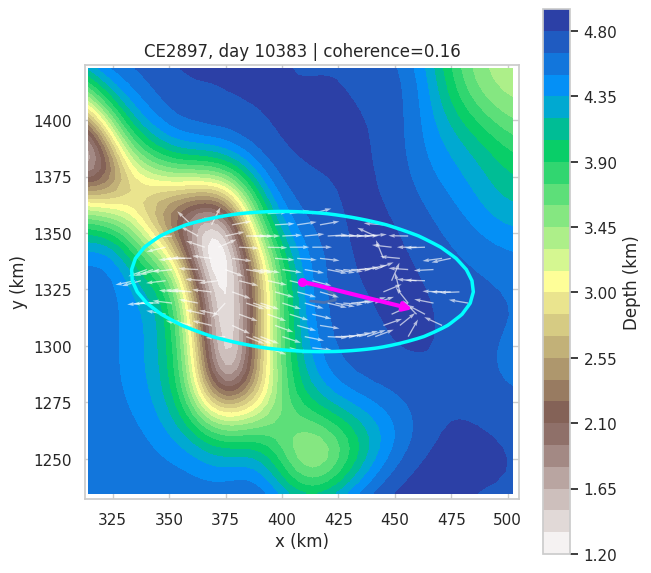

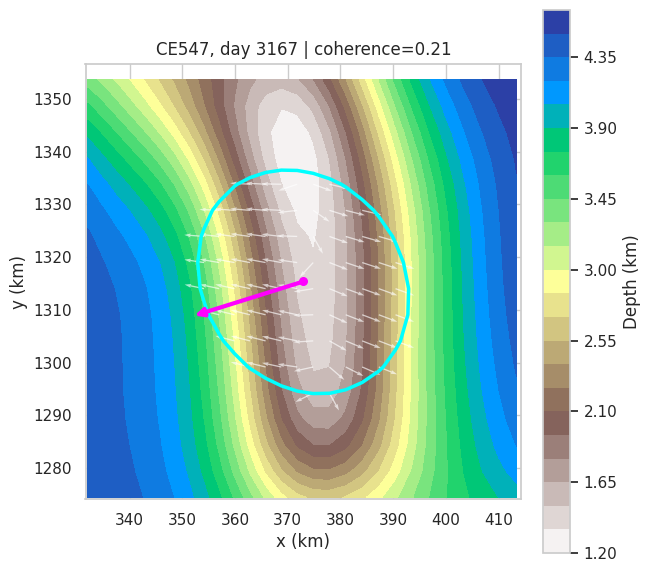

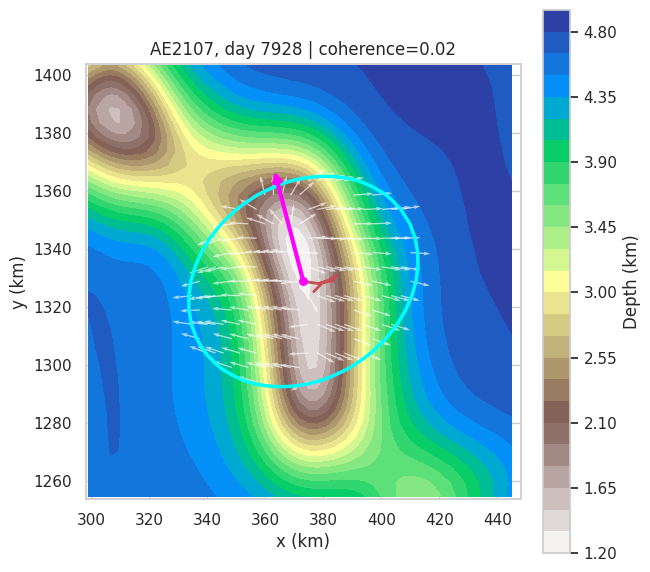

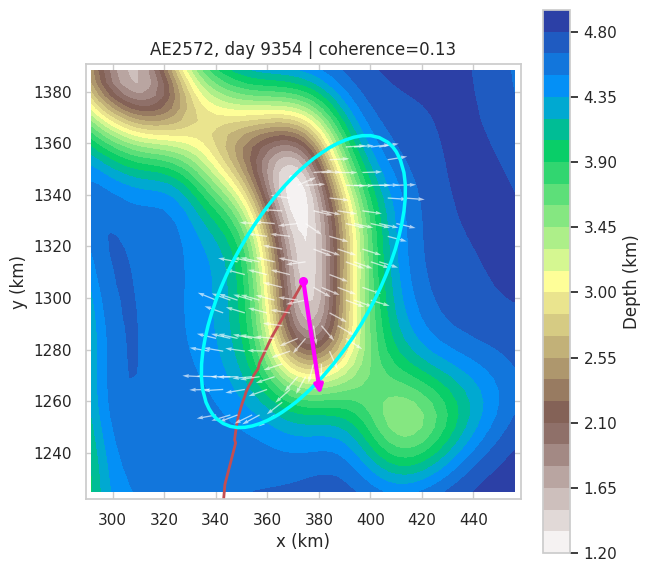

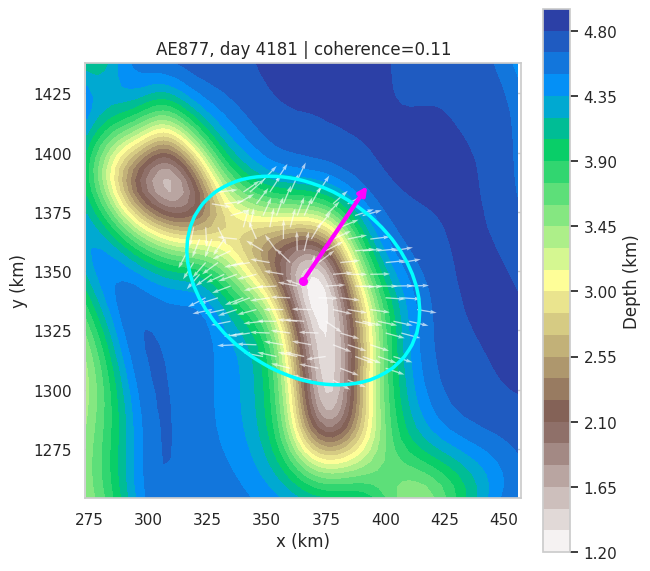

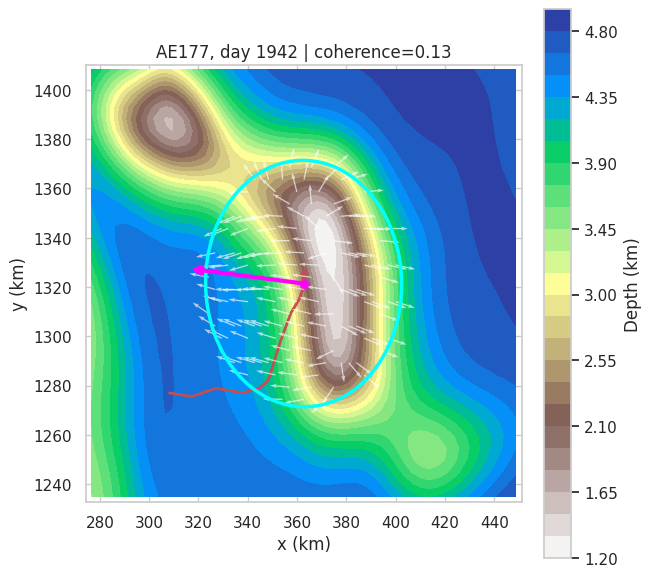

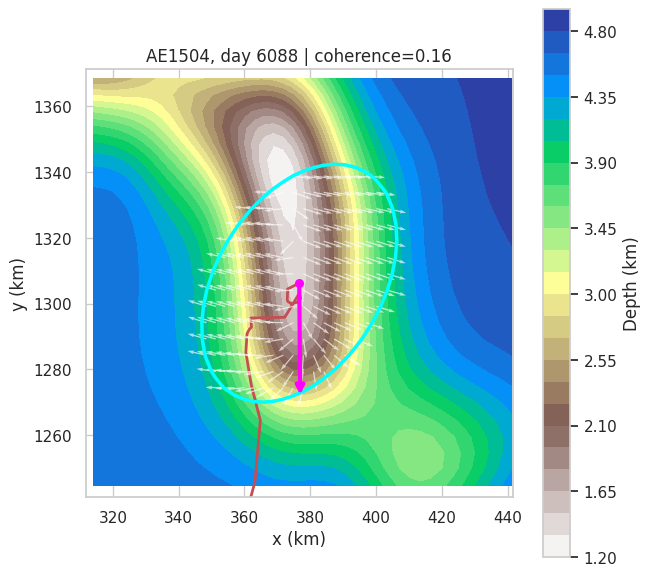

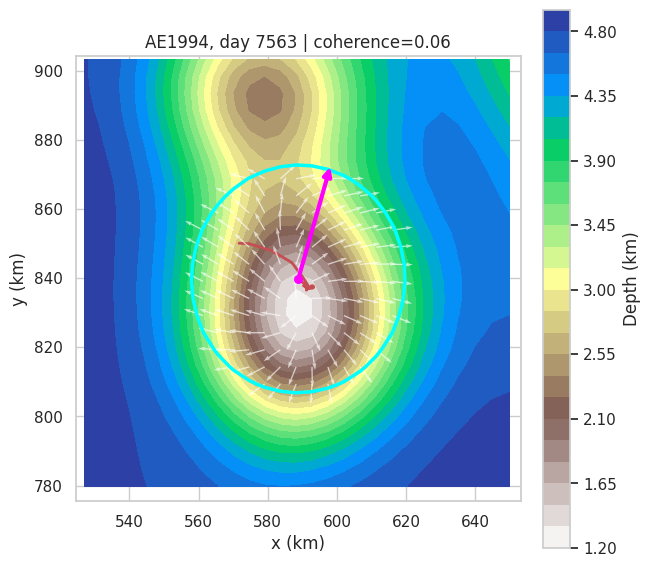

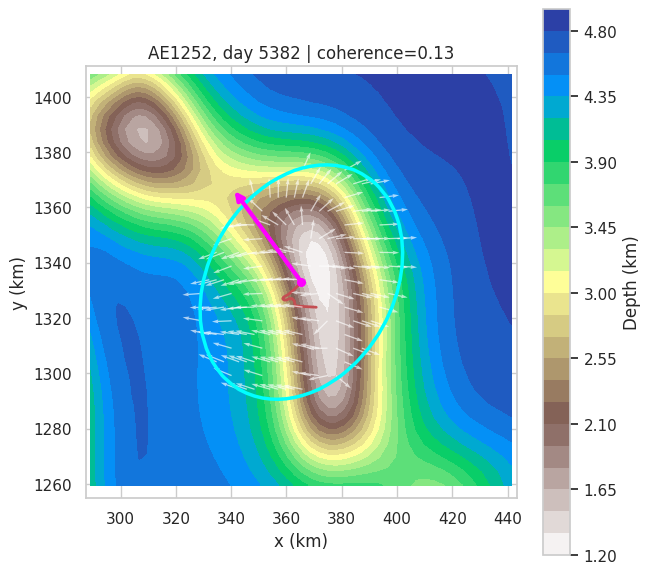

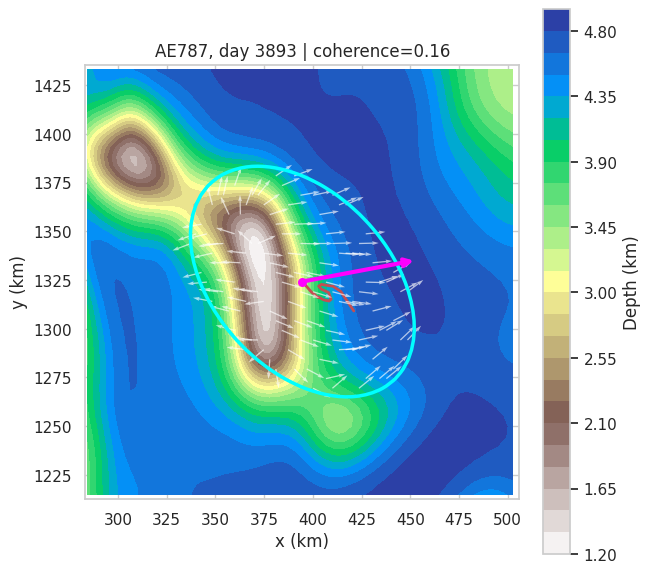

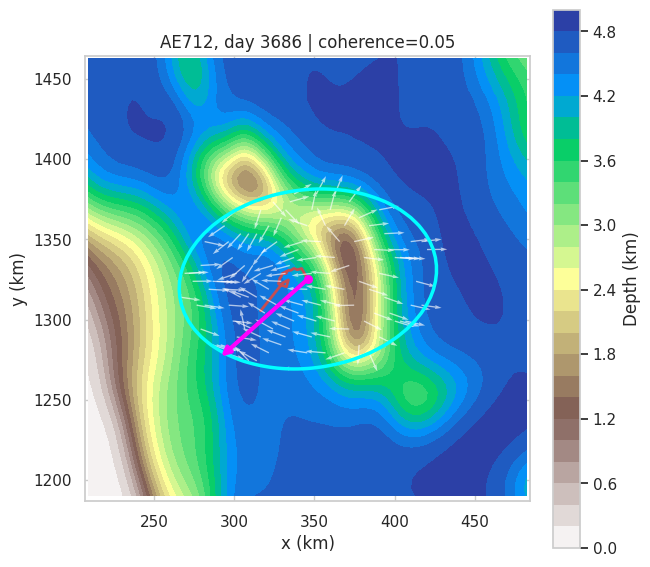

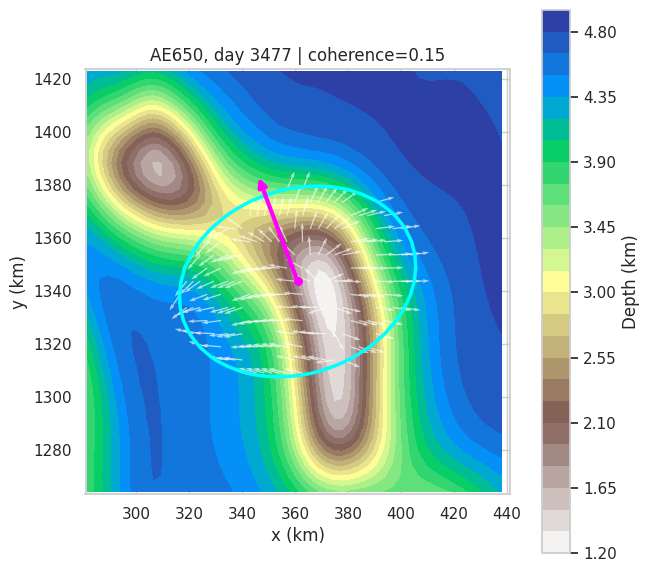

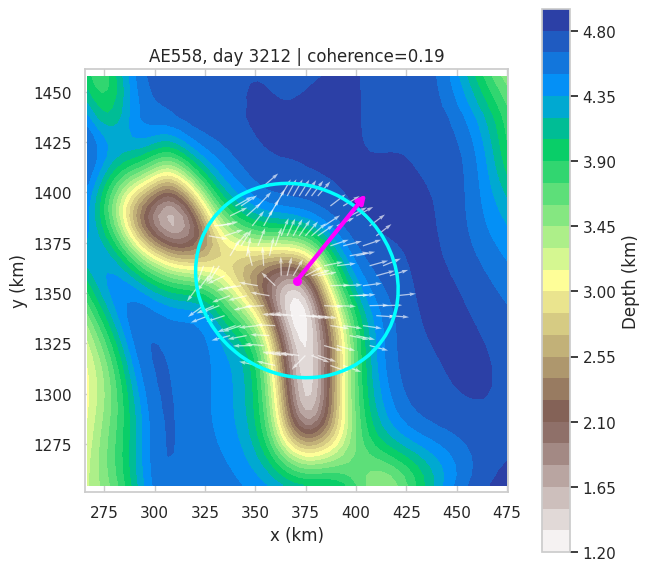

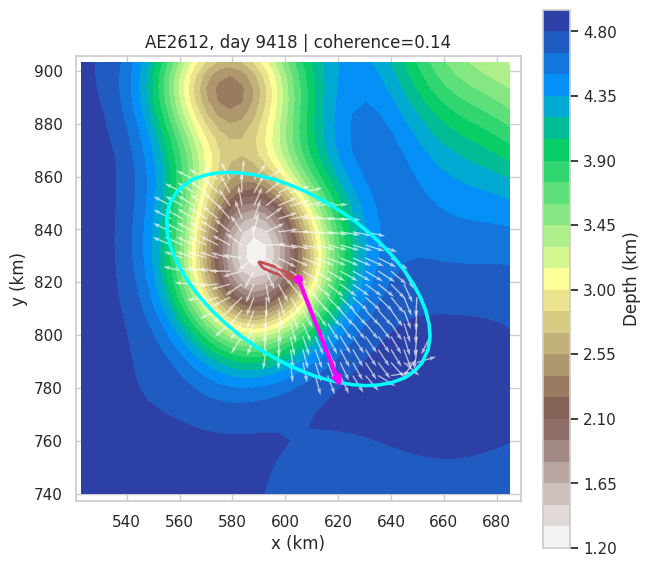

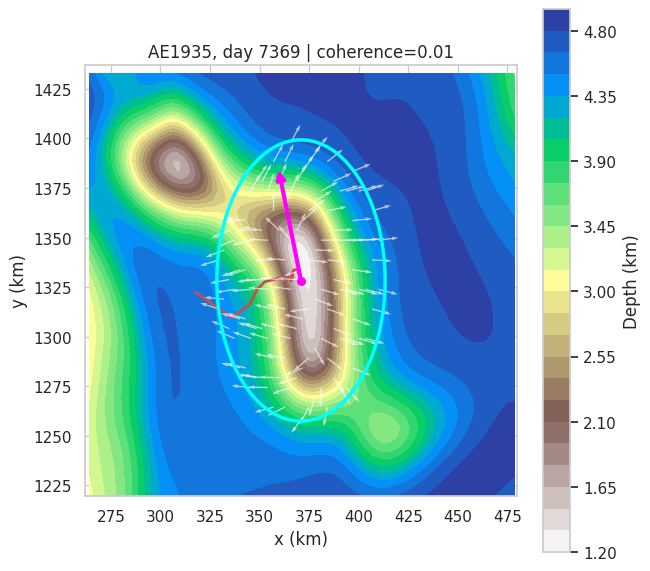

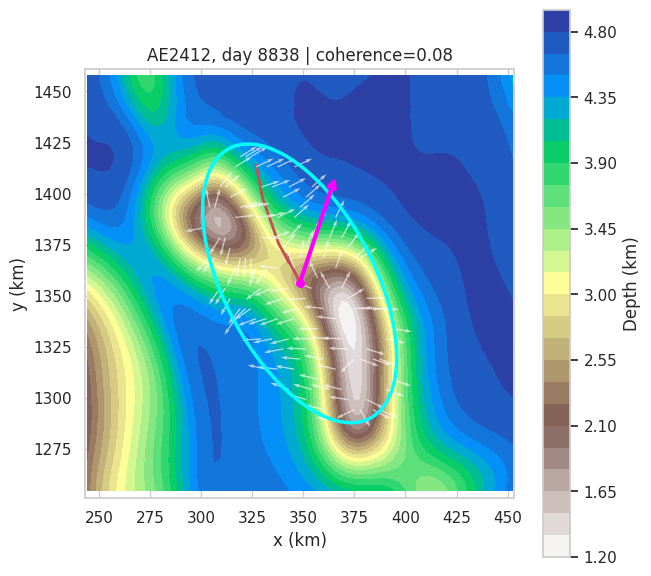

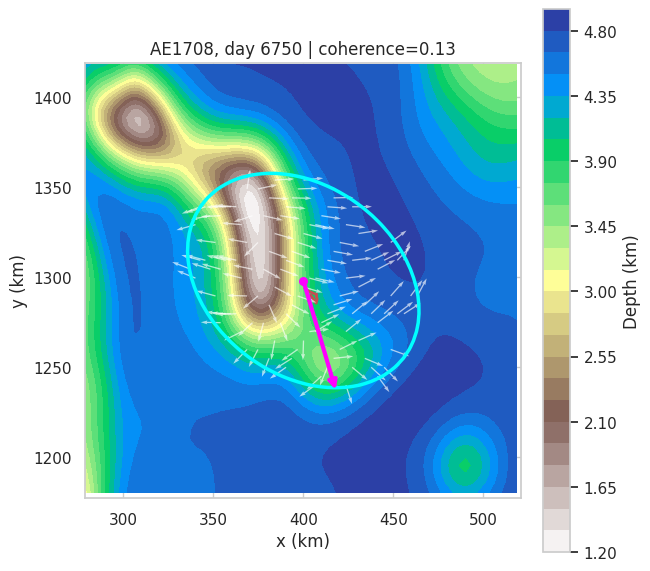

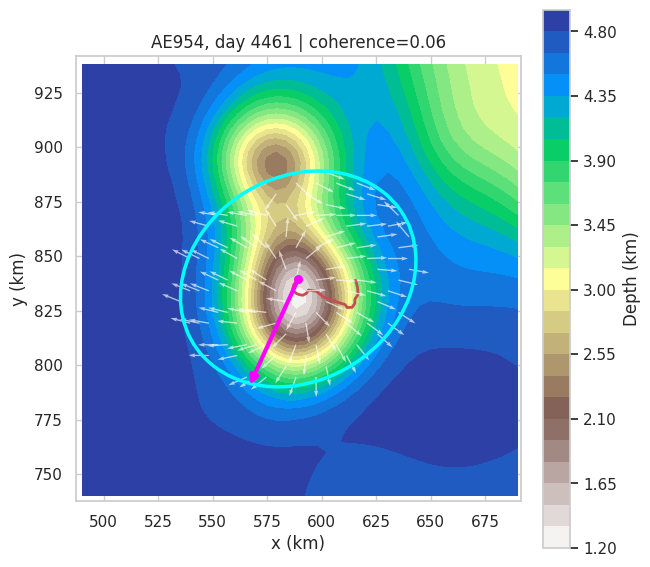

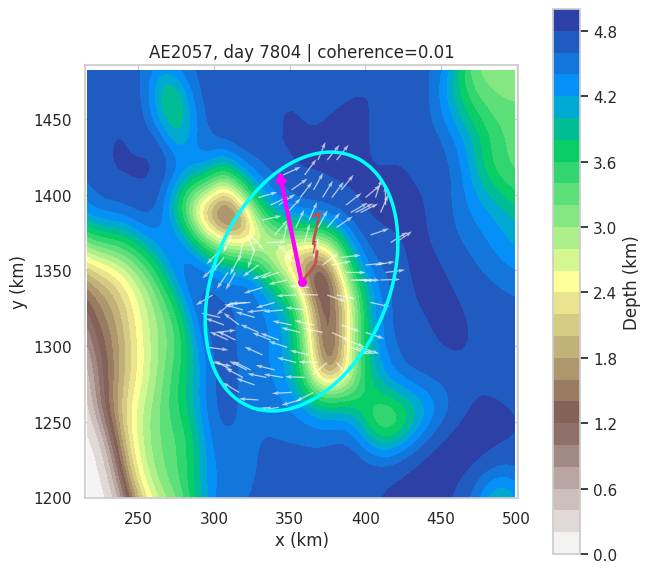

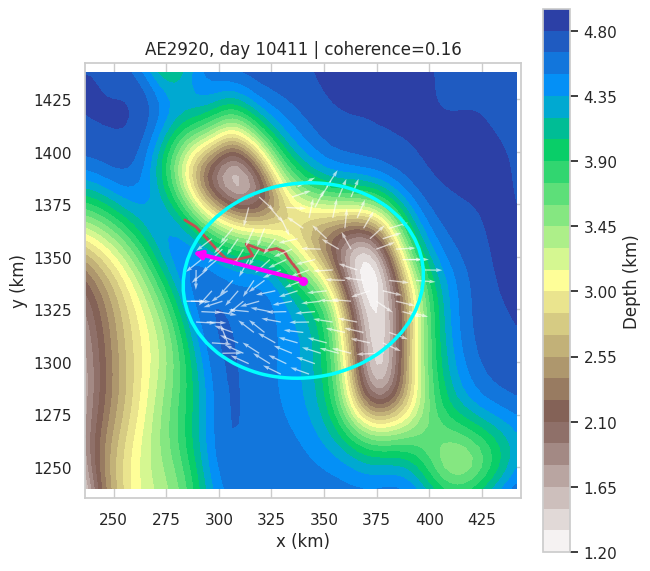

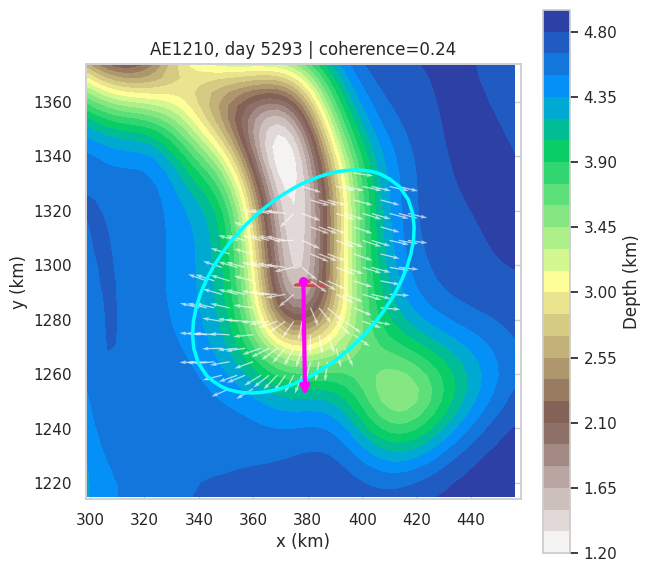

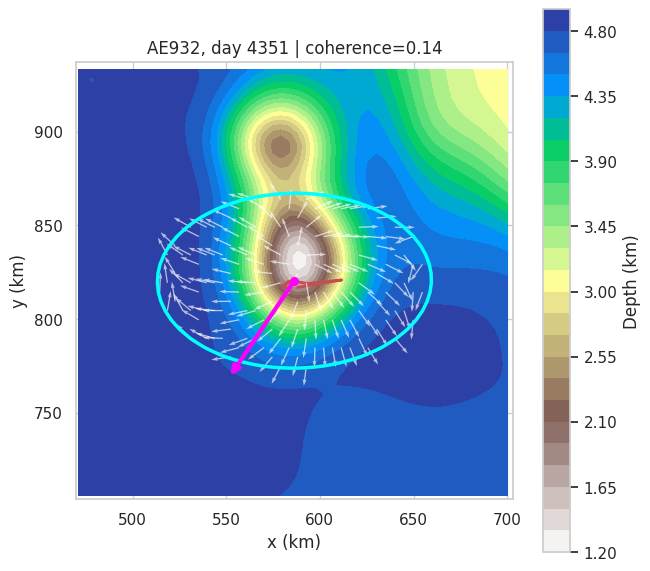

In [4]:
for _, row in events.iterrows():
    local=ept.local_esp_fields(row,grid,frac=1)
    pad=max(40,1.4*row.Rc)
    inside=((grid.X_grid>=row.xc-pad)&(grid.X_grid<=row.xc+pad)&
            (grid.Y_grid>=row.yc-pad)&(grid.Y_grid<=row.yc+pad))
    bathy=np.where((grid.mask_rho==1)&inside,grid.h/1000,np.nan)
    fig,ax=plt.subplots(figsize=(6.4,5.7),constrained_layout=True)
    cf=ax.contourf(grid.X_grid,grid.Y_grid,bathy,25,cmap="terrain_r")
    tilt.plot_ellipse(ax,row,grid,frac=1,color="cyan",lw=2.5,zorder=8)
    step=max(1,len(local)//120); arrows=local.iloc[::step]
    mag=np.hypot(arrows.environment_east,arrows.environment_north)
    valid=mag.gt(0)
    ax.quiver(arrows.x[valid],arrows.y[valid],arrows.environment_east[valid]/mag[valid],
              arrows.environment_north[valid]/mag[valid],color="white",alpha=.65,
              scale=22,width=.003,zorder=7)
    net=np.hypot(row.PV_grad_x,row.PV_grad_y)
    if np.isfinite(net) and net>0:
        length=.75*row.Rc
        ax.annotate("",xy=(row.xc+length*row.PV_grad_x/net,row.yc+length*row.PV_grad_y/net),
                    xytext=(row.xc,row.yc),arrowprops=dict(arrowstyle="-|>",color="magenta",lw=3),zorder=10)
    ax.scatter(row.xc,row.yc,c="magenta",s=30,zorder=10)
    df = vertical[(vertical.Eddy==row.Eddy)&(vertical.Day==row.Day)].copy()
    ax.plot(df.xc, df.yc, color='r'if row.Cyc=='AE' else 'b', lw=2)
    ax.set(xlim=(row.xc-pad,row.xc+pad),ylim=(row.yc-pad,row.yc+pad),aspect="equal",
           title=f"{row.Cyc}{int(row.Eddy)}, day {int(row.Day)} | coherence={row.PV_grad_topo_coherence:.2f}",
           xlabel="x (km)",ylabel="y (km)")
    fig.colorbar(cf,ax=ax,label="Depth (km)")
    plt.show()

In [5]:
pwd

'/home/z5297792/UNSW-PhD/seacofs_eddy_tilt_analysis/surface_pv_esp_gaussian'